<a href="https://colab.research.google.com/github/DesmondLo/AIVC-/blob/main/%E7%AC%AC%E4%B8%89%E5%91%A8%E4%BA%A4%E6%8E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 說明



1.   請使用Numpy完成程式碼，禁止額外套用套件，可以使用cv2_imread
2.   可以使用自己完成的副程式
3.   完成程式碼後，請與cv2的結果自行做對照
4.   程式碼練習題只有第二與第三部分，第一部分相對簡單可以自行理解



# 掛載雲端

In [5]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


# 引入套件

In [6]:
import numpy as np
import os
import cv2
from google.colab.patches import cv2_imshow

# 讀取圖片

--2026-03-02 04:40:42--  https://upload.wikimedia.org/wikipedia/zh/3/34/Lenna.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.154.240, 2620:0:861:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.154.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 160012 (156K) [image/jpeg]
Saving to: ‘lena.jpg’

lena.jpg            100%[===================>] 156.26K  --.-KB/s    in 0.04s   

2026-03-02 04:40:42 (3.76 MB/s) - ‘lena.jpg’ saved [160012/160012]



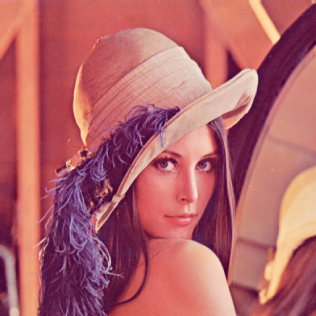

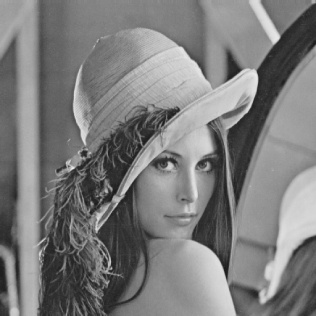

In [9]:
!wget https://upload.wikimedia.org/wikipedia/zh/3/34/Lenna.jpg -O lena.jpg
img=cv2.imread('lena.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(img)
cv2_imshow(img_gray)

圖片來源 https://upload.wikimedia.org/wikipedia/zh/3/34/Lenna.jpg

#一、Mean、Median、Maximum
###說明
*   Filter (濾波器) : 濾波器是用來修改或改變訊號的工具。濾波器可以過濾掉訊號中的特定頻率成分，或者增強特定頻率成分，以達到不同的信號處理目的。

### 常見的Filter
*   Mean Filter (均值濾波器) : 是一種常見的線性濾波器，它將一個像素周圍的鄰域像素值取平均，並將該平均值作為中心像素的新值。這種濾波器通常用於平滑圖像，減少圖像中的雜訊。

  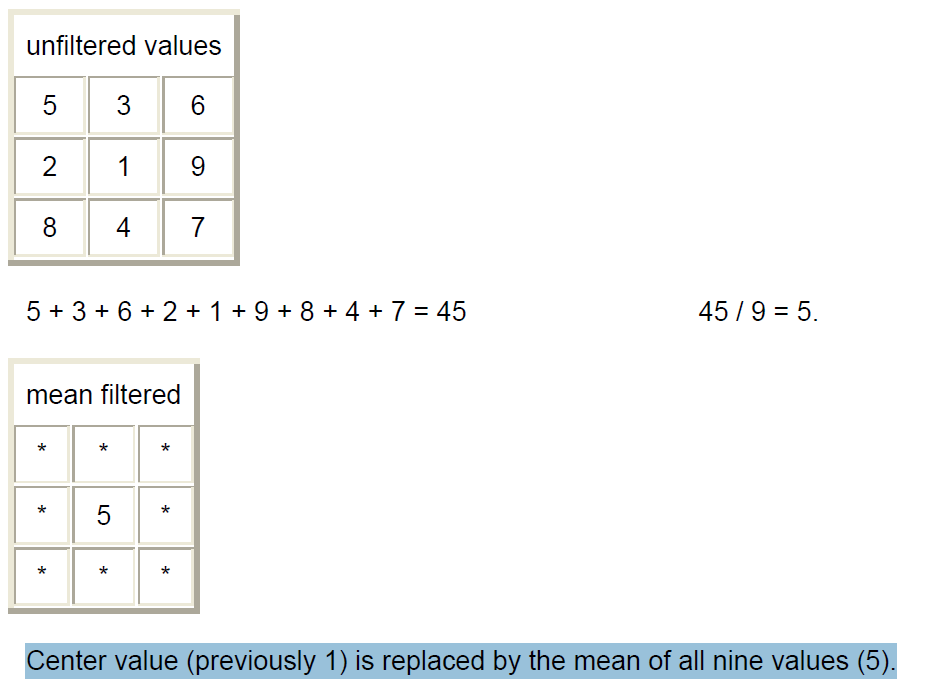

*   Median Filter (中值濾波器) : 是一種非線性濾波器，它將一個像素周圍的鄰域像素值排序後取中間值，並將該中間值作為中心像素的新值。這種濾波器在去除圖像中的椒鹽雜訊或其他突出雜訊方面效果很好。

   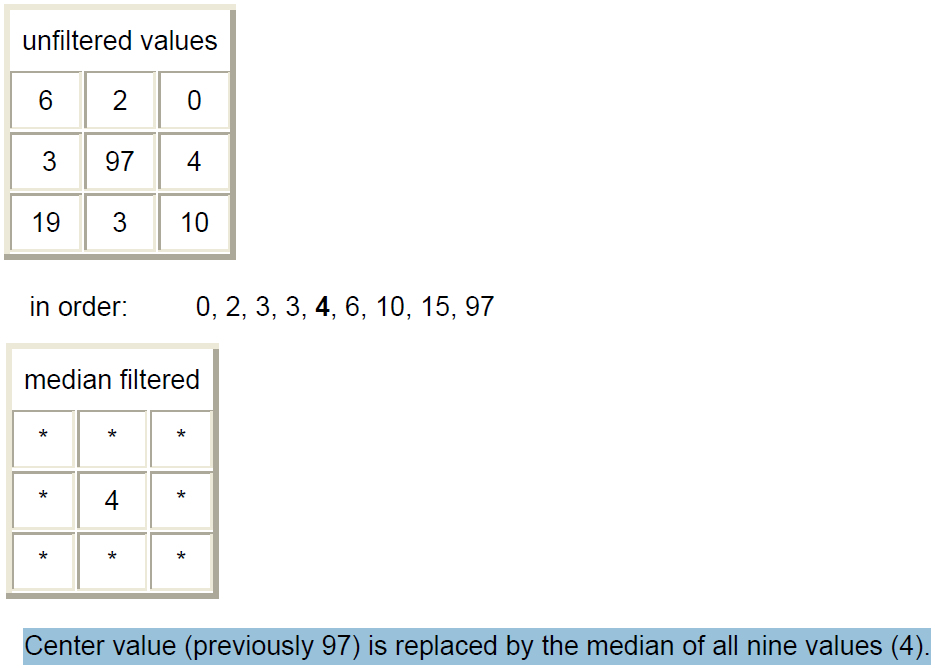

*   Maximum Filter (最大值濾波器) : 是一種非線性濾波器，它將一個像素周圍的鄰域像素值中的最大值作為中心像素的新值。這種濾波器通常用於圖像增強或檢測圖像中的局部最大值。

   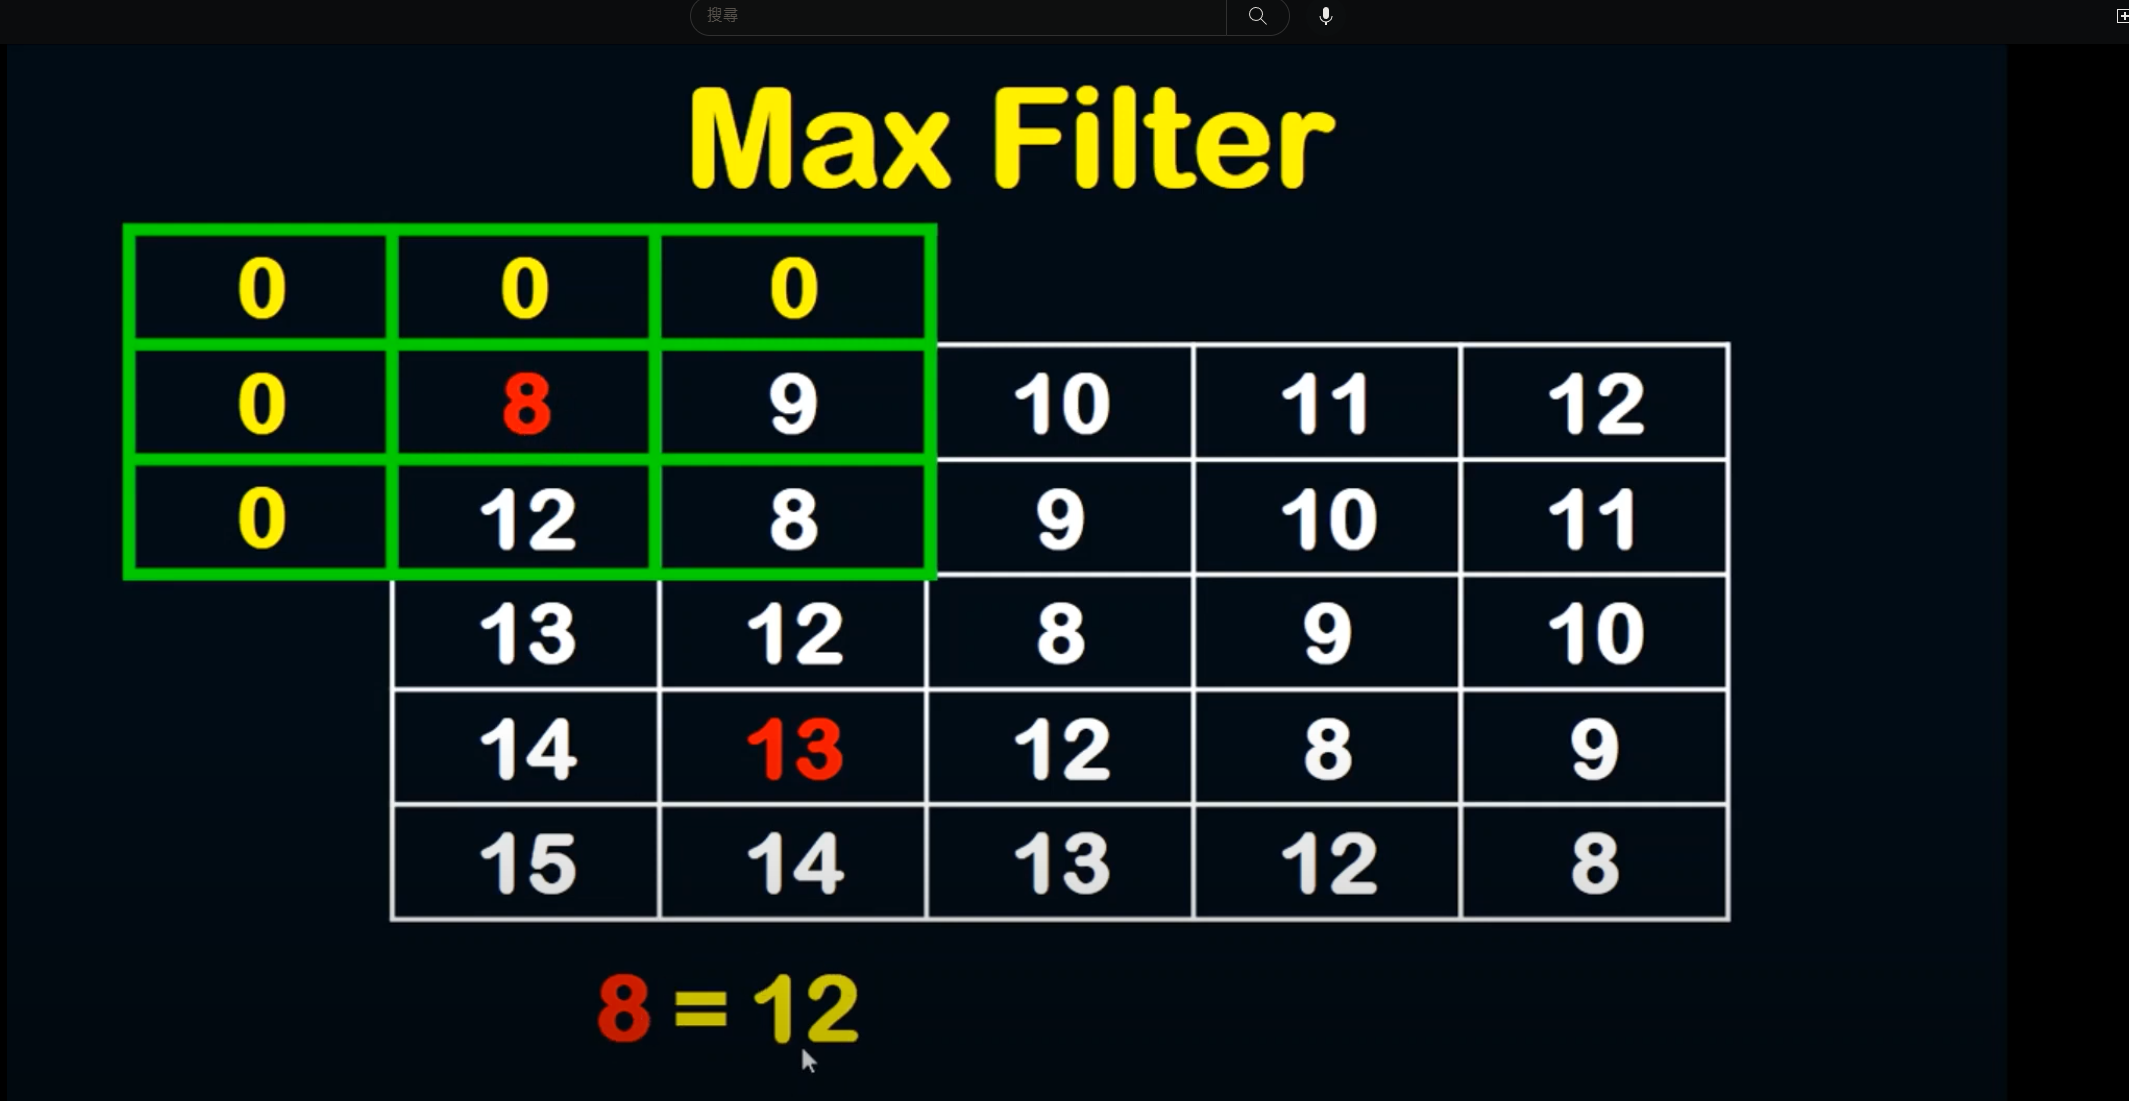


  後兩者若有人看圖後還不了解的，這邊有教學影片
  
  Median:https://www.youtube.com/watch?v=3kwH3Rb5LJ4

  Maximum:https://www.youtube.com/watch?app=desktop&v=HnwIqBWTsD0








# Mean、Median、Maximum 的程式練習


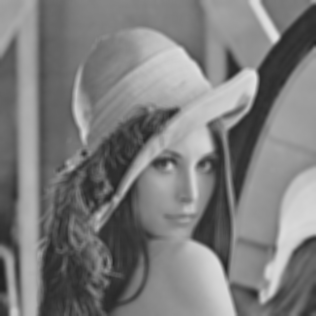

In [10]:
# 1.使用 Mean Filter 對 img_gray 進行濾波處理，使用 5x5 的濾波器核心
mean_filtered_img = cv2.blur(img_gray, (5, 5))
cv2_imshow(mean_filtered_img)

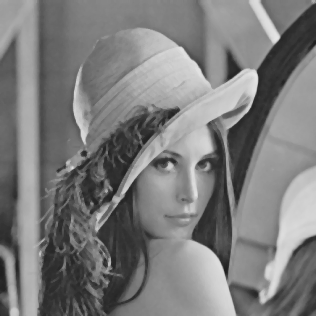

In [11]:
# 2.使用 Median Filter 對 img_gray 進行濾波處理，使用 3x3 的濾波器核心
median_filtered_img = cv2.medianBlur(img_gray, 3)
cv2_imshow(median_filtered_img)

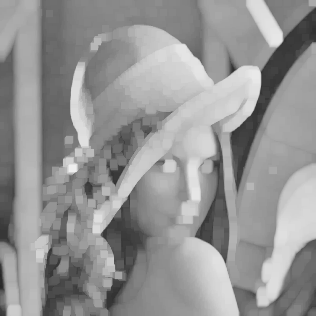

In [12]:
# 3.使用 Maximum Filter 對 img_gray 進行濾波處理，使用 7x7 的濾波器核心
max_filtered_img = cv2.dilate(img_gray, np.ones((7, 7), np.uint8))
cv2_imshow(max_filtered_img)

#二、Edge detection
## 說明
- Edge : 灰階濃度的急劇變化的地方，可以很清楚地看見輪廓。
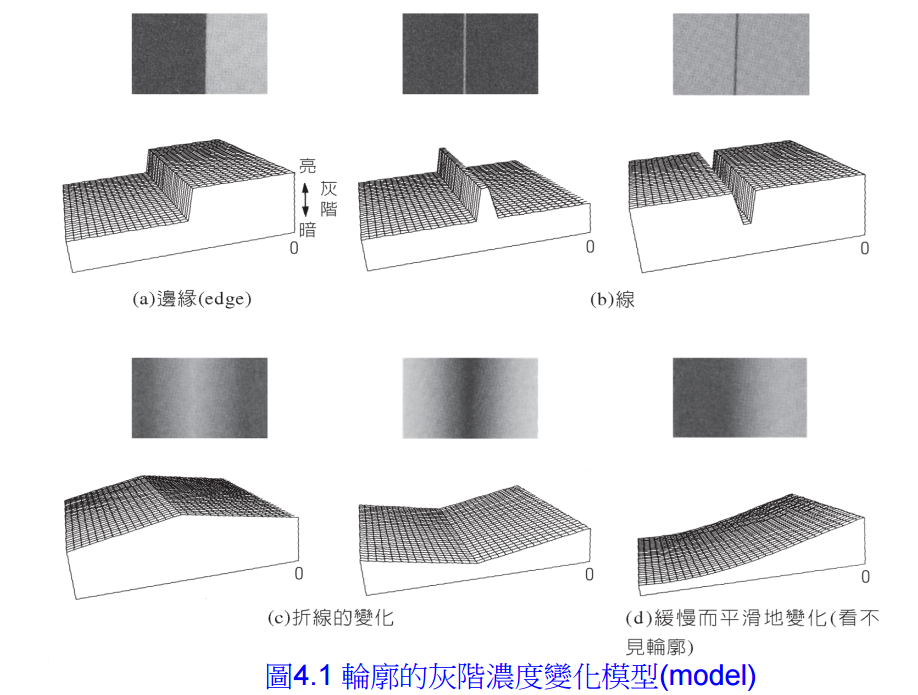
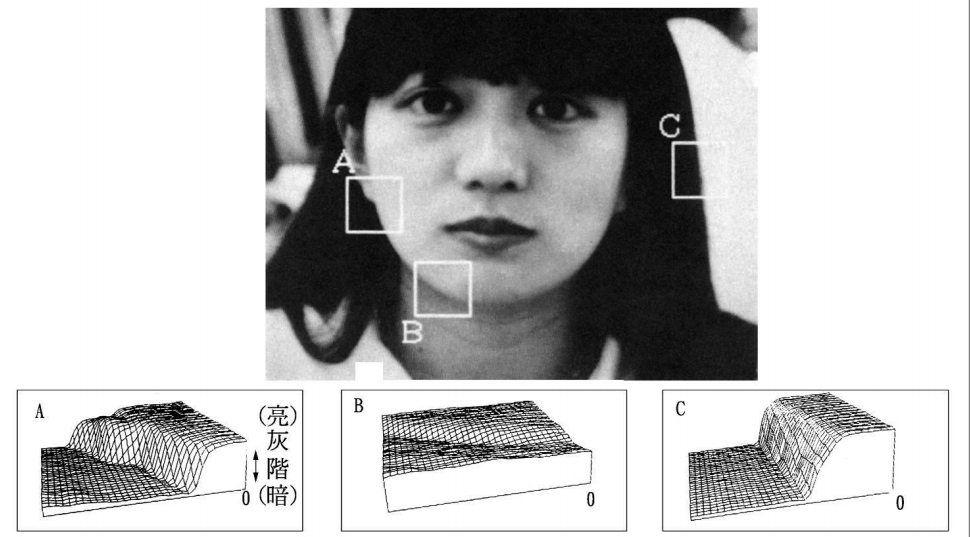
- Edge detection ： 透過偵測物體的Edge，更容易地進行特徵提取、物體檢測、圖像分割等任務。電腦視覺中經常採用Operator來進行Edge detection。
![picture](https://miro.medium.com/v2/resize:fit:1358/1*Cj8DT8wjZkpNjpJxaMnHEw.png)
- Operator : 進行edge detection在數位影像中，因為數據(Data)是以一定間隔跳躍式排列，
無法用具真正意義之微分作運算。因此取相鄰pixel之間的**差**來運算，作近似之微分。
為了進行微分運算，用相鄰pixel之間的運算來表達稱為**微分運算子**(**Operator**)。而每種operator通常分為偵測縱向和橫向的kernel/filter。




### 常見的Operator
1. A：原圖  
G：梯度
2. 將兩個分量結合為梯度  
![picture](https://wikimedia.org/api/rest_v1/media/math/render/svg/23ae6772c5f58751fc6014b71d6adafb30a31c79)
3. 可以注意不同方法中kernel的權重不一樣(代表取得不一樣的edge特徵)   

- Sobel operator
> ![picture](https://wikimedia.org/api/rest_v1/media/math/render/svg/5b89bf12f4ee3903807a4b907c53697a4423b668)  

- Prewitt operator
> ![picture](https://wikimedia.org/api/rest_v1/media/math/render/svg/89e0951634f88eb18d06923df71e89eb83e7fff3)

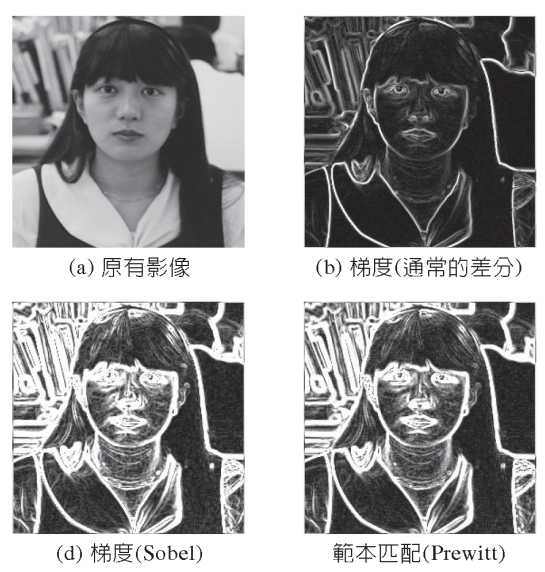

- Laplacian operator  
> 1. 拉普拉斯採用圖像的二次導數進行計算
  2. 相對於梯度有大小與方向性，拉普拉斯只有大小
  3. 拉普拉斯有很多種類  
    想了解細節可以參考這篇 --> [Link](https://medium.com/%E9%9B%BB%E8%85%A6%E8%A6%96%E8%A6%BA/%E9%82%8A%E7%B7%A3%E5%81%B5%E6%B8%AC-%E6%8B%89%E6%99%AE%E6%8B%89%E6%96%AF%E7%AE%97%E5%AD%90-laplacian-operator-ea877f1945a0)

    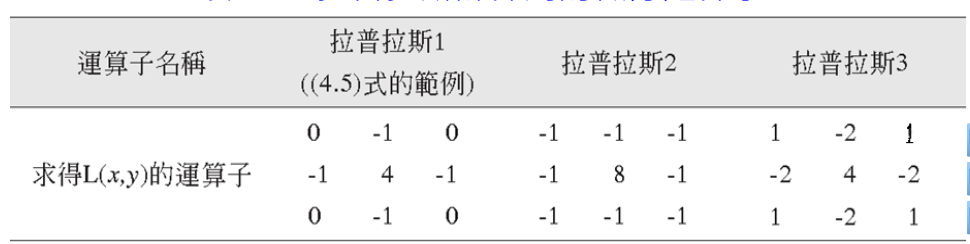
    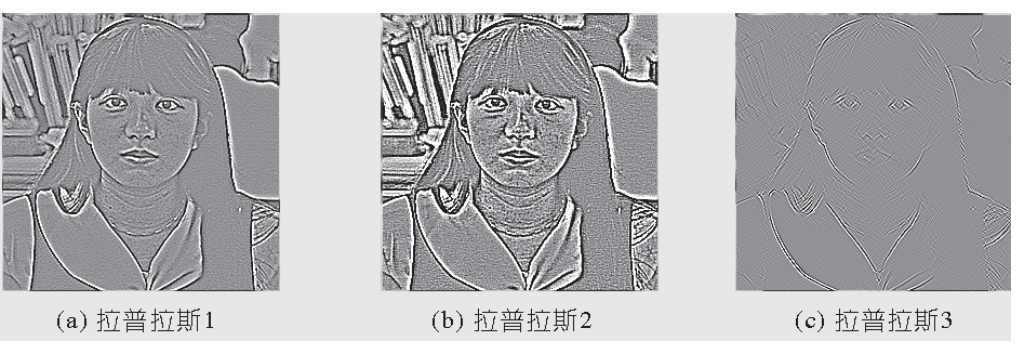

- Canny Edge Detection (詳見下一部份）A

## Edge Detection 程式碼作業


### Sobel

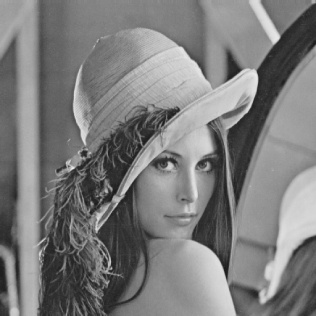

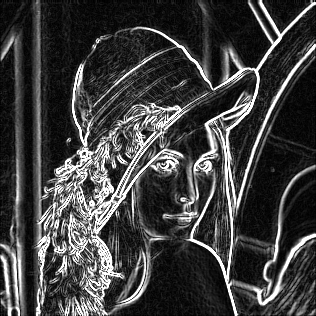

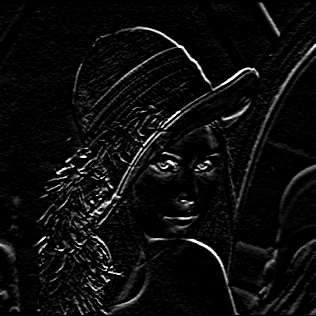

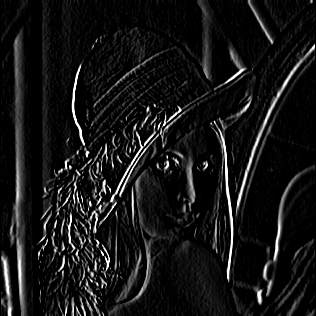

In [38]:
img_sobel, grad_x, grad_y = Sobel(img_gray)
cv2_imshow(img_gray)
cv2_imshow(img_sobel)
cv2_imshow(grad_y)
cv2_imshow(grad_x)

In [37]:
def Sobel(image):
  # 使用cv2.Sobel計算x方向的梯度
  # cv2.CV_64F 表示輸出圖像的深度為64位浮點數 保留梯度的正負值
  # (1, 0)表示計算x方向的導數 y方向為0
  # ksize=3表示使用3x3的Sobel核
  grad_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)

  # 使用cv2.Sobel計算y方向的梯度
  # (0, 1)表示計算y方向的導數 x方向為0
  grad_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

  # 將x方向梯度的絕對值轉換為8位無符號整數
  abs_grad_x = cv2.convertScaleAbs(grad_x)

  # 將y方向梯度的絕對值轉換為8位無符號整數
  abs_grad_y = cv2.convertScaleAbs(grad_y)

  # 將 x 和 y 方向的梯度絕對值以 0.5 的權重相加，得到合併的 Sobel 邊緣圖
  # 這裡的 'sobel' 實際上是梯度大小的一個近似值
  sobel = cv2.add(abs_grad_x, abs_grad_y)

  return sobel, grad_x, grad_y

### Laplacian

In [39]:
def Laplacian(image):
  # image: 輸入圖像
  # cv2.CV_8U: 輸出圖像的深度，表示8位無符號整數類型 使輸出圖像的像素值在0-255之間
  # ksize=3: 卷積核的大小
  laplacian = cv2.Laplacian(image, cv2.CV_8U, ksize=3)
  return laplacian

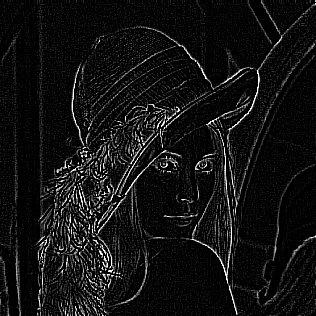

In [40]:
res = Laplacian(img_gray)
cv2_imshow(res)

#三、Canny

##說明
Canny演算法是一個複合性的邊緣偵測演算法，結合了Gaussian Filter、梯度偵測、非最大值抑制、判斷邊界四個演算法去實踐邊緣偵測。

####1. Gaussian Filter


> 用途在於減少圖像雜訊以及降低細節層次


####2. 梯度偵測

> 使用Sobel運算子來計算x方向和y方向的梯度，從而得到每一個像素的邊緣強度和方向。
計算方式前面有提到，請參考二、Edge detection


> 示意圖：（為了簡化計算，梯度的方向約略分成四種，0度、45度、90度、135度）
<br>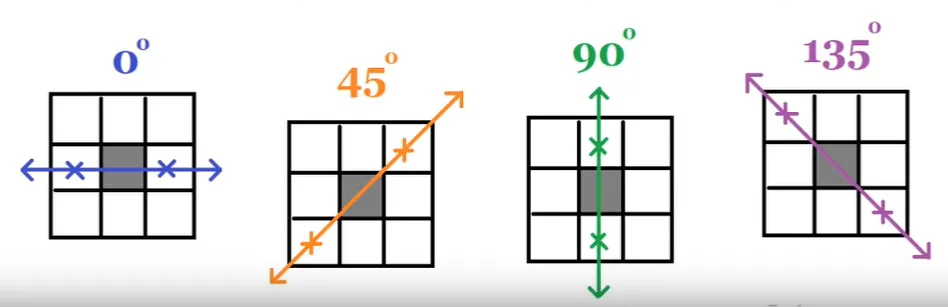</br>



####3. 非最大值抑制

> 由上一步獲得梯度大小和方向後，會掃描圖像的所有邊緣。檢查每個像素是不是在梯度方向上的領域中的局部最大值，最後你將會得到細線的二進制圖像。



> 示意圖：
<br>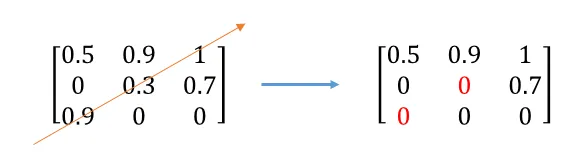</br>

<br>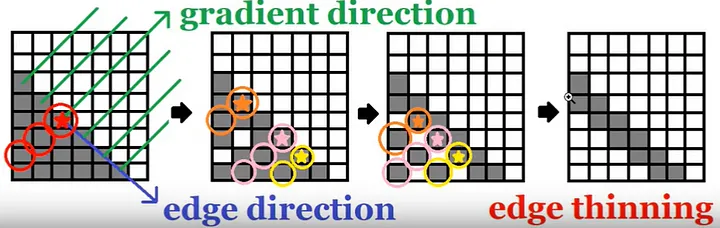</br>



####4. 判斷邊界


> 這個步驟決定哪些邊緣真正重要，以保留最終的邊緣。我們會使用兩個閾值：低閾值和高閾值。強度高於高閾值的邊緣一定被保留，低於低閾值的邊緣一定被排除，介於兩者之間的則根據其連接性決定是否保留。



*   高於高界線:一定是邊緣
*   低於低界線:一定不是邊緣
*   介於高界線與低界線:若附近有兩點高於高界線的點，則此點也視為邊緣
> 示意圖：
<br>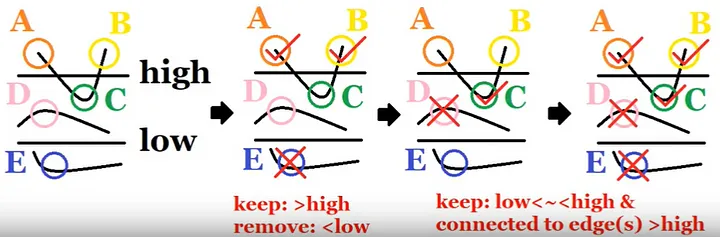</br>

###透過上述這些流程，就能找到圖像的邊緣


#####參考來源：https://medium.com/@bob800530/opencv-%E5%AF%A6%E4%BD%9C%E9%82%8A%E7%B7%A3%E5%81%B5%E6%B8%AC-canny%E6%BC%94%E7%AE%97%E6%B3%95-d6e0b92c0aa3

##Canny程式碼作業
*   完成TODO的部份，並上網查資料將你不懂的程式碼加上註解即可(必要)
*   或可以依照自己的方式重現canny演算法(非必要)

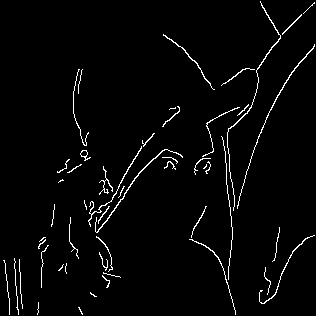

In [48]:
import numpy as np
import math
from scipy.ndimage import convolve
import numpy as np

#高斯濾波器
def gaussian_filter(kernel_size=5, sigma=1.0):
    kernel_size = int(kernel_size) // 2
    x, y = np.mgrid[-kernel_size:kernel_size+1, -kernel_size:kernel_size+1]
    g = np.exp(-(x**2 + y**2) / (2*sigma**2))
    return g / g.sum()

#梯度檢測
def gradient(image):
    #TODO sobel 橫向和縱向kernel
    Kx = np.array([[-1,0,1],
            [-2,0,2],
            [-1,0,1]])
    Ky = np.array([[1,2,1],
            [0,0,0],
            [-1,-2,-1]])

    Ix = np.zeros(image.shape)
    Iy = np.zeros(image.shape)

    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            Ix[i, j] = np.sum(Kx * image[i-1:i+2, j-1:j+2])
            Iy[i, j] = np.sum(Ky * image[i-1:i+2, j-1:j+2])

    G = np.sqrt(Ix**2 + Iy**2)
    Theta = np.arctan2(Iy, Ix)
    return G, Theta

#非極大值抑制
def non_max_suppression(gradient, direction):
    M, N = gradient.shape
    Z = np.zeros((M,N), dtype=np.int32)
    angle = direction * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1,M-1):
        for j in range(1,N-1):
            try:
                q = 255
                r = 255

                #angle 0
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = gradient[i, j+1]
                    r = gradient[i, j-1]
                #angle 45
                elif (22.5 <= angle[i,j] < 67.5):
                    q = gradient[i+1, j-1]
                    r = gradient[i-1, j+1]
                #angle 90
                elif (67.5 <= angle[i,j] < 112.5):
                    q = gradient[i+1, j]
                    r = gradient[i-1, j]
                #angle 135
                elif (112.5 <= angle[i,j] < 157.5):
                    q = gradient[i-1, j-1]
                    r = gradient[i+1, j+1]

                if (gradient[i,j] >= q) and (gradient[i,j] >= r):
                    Z[i,j] = gradient[i,j]
                else:
                    Z[i,j] = 0

            except IndexError as e:
                pass

    return Z

#雙閥值
def threshold_and_edge_tracking(gradient, low_threshold, high_threshold):
    M, N = gradient.shape
    res = np.zeros((M,N), dtype=np.int32)

    strong = 255
    weak = 25

    strong_i, strong_j = np.where(gradient >= high_threshold)
    zeros_i, zeros_j = np.where(gradient < low_threshold)

    weak_i, weak_j = np.where((gradient <= high_threshold) & (gradient >= low_threshold))

    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak

    return res

#判斷邊界
def apply_hysteresis(image, weak=25, strong=255):
    M, N = image.shape
    for i in range(1, M-1):
        for j in range(1, N-1):
            if image[i,j] == weak:
                if ((image[i+1, j-1] == strong) or (image[i+1, j] == strong) or (image[i+1, j+1] == strong)
                    or (image[i, j-1] == strong) or (image[i, j+1] == strong)
                    or (image[i-1, j-1] == strong) or (image[i-1, j] == strong) or (image[i-1, j+1] == strong)):
                    image[i, j] = strong
                else:
                    image[i, j] = 0
    return image
#canny演算法
def canny_edge_detection(image, sigma=1.0, low_threshold=100, high_threshold=200):
    filtered_image = convolve(image, gaussian_filter(5, sigma))
    gradient_magnitude, gradient_direction = gradient(filtered_image)
    non_max_img = non_max_suppression(gradient_magnitude, gradient_direction)
    thresholded = threshold_and_edge_tracking(non_max_img, low_threshold, high_threshold)
    final_img = apply_hysteresis(thresholded)
    return final_img

canny_img = canny_edge_detection(img_gray, sigma=1, low_threshold=100, high_threshold=200)
cv2_imshow(canny_img)

##使用Canny演算法的結果

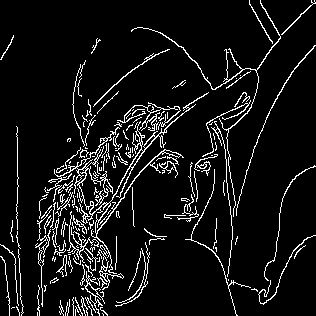

In [49]:
# 使用Canny演算法
# edges = cv2.Canny(gray, low_threshold, high_threshold)
edges = cv2.Canny(img_gray, 100, 200)
# 顯示結果
cv2_imshow(edges)